# Dynamic IDK Cascades — Simple Streaming Research Notebook

This notebook implements the Random Forest skip-decision IDK cascade in small, visible steps.

It does **not** require `data/imagenetv2` in this project. Images stream from Hugging Face when dataset/model cells run. Cached model outputs still save to `artifacts/` so expensive inference does not need to be repeated.

In [30]:
from pathlib import Path
import time

import numpy as np

HF_DATASET = "vaishaal/ImageNetV2"

VARIANT_FOLDERS = {
    "matched-frequency": "imagenetv2-matched-frequency-format-val",
    "threshold-0.7": "imagenetv2-threshold0.7-format-val",
    "top-images": "imagenetv2-top-images-format-val",
}

VARIANT_URLS = {
    "matched-frequency": "https://huggingface.co/datasets/vaishaal/ImageNetV2/resolve/main/imagenetv2-matched-frequency.tar.gz",
    "threshold-0.7": "https://huggingface.co/datasets/vaishaal/ImageNetV2/resolve/main/imagenetv2-threshold0.7.tar.gz",
    "top-images": "https://huggingface.co/datasets/vaishaal/ImageNetV2/resolve/main/imagenetv2-top-images.tar.gz",
}

## 1. Stream ImageNet-V2 from Hugging Face

The Hugging Face dataset streams rows with:

- `jpeg`: PIL image
- `__key__`: archive path, including the class folder
- `__url__`: which ImageNet-V2 archive the row came from

The class label is derived from the numeric folder in `__key__`.

In [31]:
def label_from_key(key):
    # Example key: imagenetv2-matched-frequency-format-val/986/image_id
    return int(key.split("/")[1])


def stream_imagenet_v2_rows(variant, max_samples=None):
    from datasets import load_dataset

    if variant not in VARIANT_FOLDERS:
        choices = ", ".join(VARIANT_FOLDERS)
        raise ValueError(f"Unknown variant '{variant}'. Choose one of: {choices}")

    stream = load_dataset(
        "webdataset",
        data_files={"train": VARIANT_URLS[variant]},
        split="train",
        streaming=True,
    )

    emitted = 0
    for row in stream:
        yield {
            "image": row["jpeg"].convert("RGB"),
            "label": label_from_key(row["__key__"]),
            "key": row["__key__"],
        }
        emitted += 1
        if max_samples is not None and emitted >= max_samples:
            break


def show_stream_examples(variant, n=3):
    for row in stream_imagenet_v2_rows(variant, max_samples=n):
        print(variant, row["label"], row["key"])

### Quick streaming check

This reads only a few examples. It requires internet but does not store raw images in the project.

In [32]:
for variant in VARIANT_FOLDERS:
    show_stream_examples(variant, n=2)

matched-frequency 986 imagenetv2-matched-frequency-format-val/986/838e9b4f82c96029ee35b303222bc3bc208b70a2
matched-frequency 986 imagenetv2-matched-frequency-format-val/986/eb4704a178f0c5f63e9e63cf783630b57b074f11
threshold-0.7 986 imagenetv2-threshold0.7-format-val/986/bbb3cc1e48a859f822615d8ec07b59f45110def1
threshold-0.7 986 imagenetv2-threshold0.7-format-val/986/fbc27c780ef8f6c186398d5ca8e7c486a6e76d5d
top-images 986 imagenetv2-top-images-format-val/986/1568a7ab37ad14b8e1a88e424b3dcd5ed4f3d29a
top-images 986 imagenetv2-top-images-format-val/986/838e9b4f82c96029ee35b303222bc3bc208b70a2


## 2. PyTorch iterable dataset

This wrapper applies the model transform and yields `(image_tensor, label, key)`.

In [33]:
def make_streaming_loader(variant, transform, batch_size=32, max_samples=None, num_workers=0):
    import torch
    from torch.utils.data import DataLoader, IterableDataset

    class ImageNetV2StreamDataset(IterableDataset):
        def __iter__(self):
            for row in stream_imagenet_v2_rows(variant, max_samples=max_samples):
                yield transform(row["image"]), row["label"], row["key"]

    return DataLoader(
        ImageNetV2StreamDataset(),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )

## 3. Load pretrained classifiers

The paper uses ResNet-18, ResNet-34, ResNet-152, and a ViT final-stage variant.

In [34]:
def load_model(model_name, device="cpu"):
    from torchvision import models

    if model_name == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
        transform = weights.transforms()
    elif model_name == "resnet34":
        weights = models.ResNet34_Weights.DEFAULT
        model = models.resnet34(weights=weights)
        transform = weights.transforms()
    elif model_name == "resnet152":
        weights = models.ResNet152_Weights.DEFAULT
        model = models.resnet152(weights=weights)
        transform = weights.transforms()
    elif model_name == "vit_base_patch16_224":
        import timm
        from timm.data import create_transform, resolve_data_config
        model = timm.create_model(model_name, pretrained=True)
        transform = create_transform(**resolve_data_config({}, model=model))
    else:
        raise ValueError(f"Unknown model: {model_name}")

    model = model.to(device)
    model.eval()
    return model, transform

## 4. Cache classifier outputs

This is the expensive part. Use `max_samples` for small tests. Set `max_samples=None` for the full 10k-image variant.

In [ ]:
def cache_logits(variant, model_name, output_file, batch_size=32, device="cpu", max_samples=None, num_workers=0):
    import torch

    output_file = Path(output_file)
    output_file.parent.mkdir(parents=True, exist_ok=True)

    model, transform = load_model(model_name, device=device)
    loader = make_streaming_loader(
        variant,
        transform,
        batch_size=batch_size,
        max_samples=max_samples,
        num_workers=num_workers,
    )

    all_probs = []
    all_labels = []
    all_preds = []
    all_times = []
    all_keys = []
    processed = 0

    with torch.inference_mode():
        for images, labels, keys in loader:
            images = images.to(device)
            if device.startswith("cuda"):
                torch.cuda.synchronize()
            start = time.perf_counter()
            logits = model(images)
            if device.startswith("cuda"):
                torch.cuda.synchronize()
            elapsed_ms = (time.perf_counter() - start) * 1000

            probs = torch.softmax(logits, dim=1).cpu().numpy().astype(np.float32)
            all_probs.append(probs)
            all_labels.append(labels.numpy().astype(np.int64))
            all_preds.append(np.argmax(probs, axis=1).astype(np.int64))
            all_times.extend([elapsed_ms / len(images)] * len(images))
            all_keys.extend(list(keys))

            processed += len(images)
            print(f"{model_name} {variant}: processed {processed} images")

    np.savez_compressed(
        output_file,
        probabilities=np.concatenate(all_probs),
        labels=np.concatenate(all_labels),
        predictions=np.concatenate(all_preds),
        times_ms=np.array(all_times, dtype=np.float64),
        keys=np.array(all_keys, dtype=str),
        model_name=np.array(model_name),
        variant=np.array(variant),
    )
    print(f"Saved {output_file}")
    return output_file

### Tiny inference smoke test

This streams only two images and runs ResNet-18. It verifies the full streaming/model/cache path.

In [36]:
# Uncomment when you want to verify the live streaming inference path.
cache_logits(
    "matched-frequency",
    "resnet18",
    "artifacts/smoke_stream_resnet18.npz",
    batch_size=1,
    max_samples=2,
)

resnet18 matched-frequency: processed 1 images
resnet18 matched-frequency: processed 2 images
Saved artifacts/smoke_stream_resnet18.npz


PosixPath('artifacts/smoke_stream_resnet18.npz')

### Full cache examples

Run these one at a time. Full CPU runs can take a long time.

In [37]:
cache_logits("matched-frequency", "resnet18",  "artifacts/matched_resnet18.npz",  batch_size=32)
cache_logits("matched-frequency", "resnet34",  "artifacts/matched_resnet34.npz",  batch_size=32)
cache_logits("matched-frequency", "resnet152", "artifacts/matched_resnet152.npz", batch_size=16)

# cache_logits("top-images", "resnet18",  "artifacts/top_resnet18.npz",  batch_size=32)
# cache_logits("top-images", "resnet34",  "artifacts/top_resnet34.npz",  batch_size=32)
# cache_logits("top-images", "resnet152", "artifacts/top_resnet152.npz", batch_size=16)

# cache_logits("threshold-0.7", "resnet18",  "artifacts/threshold07_resnet18.npz",  batch_size=32)
# cache_logits("threshold-0.7", "resnet34",  "artifacts/threshold07_resnet34.npz",  batch_size=32)
# cache_logits("threshold-0.7", "resnet152", "artifacts/threshold07_resnet152.npz", batch_size=16)

resnet18 matched-frequency: processed 32 images
resnet18 matched-frequency: processed 64 images
resnet18 matched-frequency: processed 96 images
resnet18 matched-frequency: processed 128 images
resnet18 matched-frequency: processed 160 images
resnet18 matched-frequency: processed 192 images
resnet18 matched-frequency: processed 224 images
resnet18 matched-frequency: processed 256 images
resnet18 matched-frequency: processed 288 images
resnet18 matched-frequency: processed 320 images
resnet18 matched-frequency: processed 352 images
resnet18 matched-frequency: processed 384 images
resnet18 matched-frequency: processed 416 images
resnet18 matched-frequency: processed 448 images
resnet18 matched-frequency: processed 480 images
resnet18 matched-frequency: processed 512 images
resnet18 matched-frequency: processed 544 images
resnet18 matched-frequency: processed 576 images
resnet18 matched-frequency: processed 608 images
resnet18 matched-frequency: processed 640 images
resnet18 matched-freque

100%|██████████| 83.3M/83.3M [00:00<00:00, 174MB/s]


resnet34 matched-frequency: processed 32 images
resnet34 matched-frequency: processed 64 images
resnet34 matched-frequency: processed 96 images
resnet34 matched-frequency: processed 128 images
resnet34 matched-frequency: processed 160 images
resnet34 matched-frequency: processed 192 images
resnet34 matched-frequency: processed 224 images
resnet34 matched-frequency: processed 256 images
resnet34 matched-frequency: processed 288 images
resnet34 matched-frequency: processed 320 images
resnet34 matched-frequency: processed 352 images
resnet34 matched-frequency: processed 384 images
resnet34 matched-frequency: processed 416 images
resnet34 matched-frequency: processed 448 images
resnet34 matched-frequency: processed 480 images
resnet34 matched-frequency: processed 512 images
resnet34 matched-frequency: processed 544 images
resnet34 matched-frequency: processed 576 images
resnet34 matched-frequency: processed 608 images
resnet34 matched-frequency: processed 640 images
resnet34 matched-freque

100%|██████████| 230M/230M [00:01<00:00, 152MB/s] 


resnet152 matched-frequency: processed 16 images
resnet152 matched-frequency: processed 32 images
resnet152 matched-frequency: processed 48 images
resnet152 matched-frequency: processed 64 images
resnet152 matched-frequency: processed 80 images
resnet152 matched-frequency: processed 96 images
resnet152 matched-frequency: processed 112 images
resnet152 matched-frequency: processed 128 images
resnet152 matched-frequency: processed 144 images
resnet152 matched-frequency: processed 160 images
resnet152 matched-frequency: processed 176 images
resnet152 matched-frequency: processed 192 images
resnet152 matched-frequency: processed 208 images
resnet152 matched-frequency: processed 224 images
resnet152 matched-frequency: processed 240 images
resnet152 matched-frequency: processed 256 images
resnet152 matched-frequency: processed 272 images
resnet152 matched-frequency: processed 288 images
resnet152 matched-frequency: processed 304 images
resnet152 matched-frequency: processed 320 images
resnet

PosixPath('artifacts/matched_resnet152.npz')

## 5. Random Forest skip model

Features from classifier A:

- confidence
- entropy
- top-1/top-2 margin

Labels:

- `0 = Skip B` when B would IDK
- `1 = Run B` when B would confidently predict

In [56]:
SKIP = 0
PREDICT = 1


def load_cache(path):
    return dict(np.load(path, allow_pickle=False))


def confidence(cache):
    return cache["probabilities"].max(axis=1)


def skip_features(probabilities, eps=1e-12):
    conf = probabilities.max(axis=1)
    entropy = -(probabilities * np.log(probabilities + eps)).sum(axis=1)
    top_two = np.partition(probabilities, kth=-2, axis=1)[:, -2:]
    top_two.sort(axis=1)
    margin = top_two[:, 1] - top_two[:, 0]
    return np.column_stack([conf, entropy, margin]).astype(np.float32)


def build_skip_dataset(a_cache, b_cache, a_threshold=0.5, b_threshold=0.5):
    a_conf = confidence(a_cache)
    b_conf = confidence(b_cache)
    a_idk = a_conf < a_threshold

    X = skip_features(a_cache["probabilities"][a_idk])
    y = np.where(b_conf[a_idk] < b_threshold, SKIP, PREDICT).astype(np.int64)
    return X, y


def train_rf_skipper(training_pairs, a_threshold=0.5, b_threshold=0.5):
    from sklearn.ensemble import RandomForestClassifier

    X_parts = []
    y_parts = []
    for a_path, b_path in training_pairs:
        X, y = build_skip_dataset(load_cache(a_path), load_cache(b_path), a_threshold, b_threshold)
        X_parts.append(X)
        y_parts.append(y)

    X_train = np.concatenate(X_parts)
    y_train = np.concatenate(y_parts)

    rf = RandomForestClassifier(
        n_estimators=50,
        max_depth=4,
        min_samples_leaf=40,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    print("training rows:", len(y_train), "skip:", int((y_train == SKIP).sum()), "predict:", int((y_train == PREDICT).sum()))
    return rf

## 6. Cascade evaluation

Compare no-skip, threshold-skip, and RF-skip policies from cached probabilities/timings.

In [57]:
def evaluate_cascade(a_cache, b_cache, c_cache, strategy, rf=None, a_threshold=0.5, b_threshold=0.5, threshold_skip=0.3):
    labels = a_cache["labels"]
    final_preds = np.empty_like(labels)
    total_time = a_cache["times_ms"].astype(float).copy()

    a_conf = confidence(a_cache)
    b_conf = confidence(b_cache)

    a_successes = 0
    b_successes = 0
    skips = 0
    c_runs = 0
    skip_truth = []
    skip_pred = []

    for i in range(len(labels)):
        if a_conf[i] >= a_threshold:
            final_preds[i] = a_cache["predictions"][i]
            a_successes += 1
            continue

        b_would_idk = b_conf[i] < b_threshold
        should_skip = False

        if strategy == "threshold":
            should_skip = a_conf[i] < threshold_skip
        elif strategy == "rf":
            if rf is None:
                raise ValueError("RF strategy requires a trained rf model")
            features = skip_features(a_cache["probabilities"][i:i+1])
            should_skip = int(rf.predict(features)[0]) == SKIP
        elif strategy != "no-skip":
            raise ValueError("strategy must be no-skip, threshold, or rf")

        if strategy in {"threshold", "rf"}:
            skip_truth.append(SKIP if b_would_idk else PREDICT)
            skip_pred.append(SKIP if should_skip else PREDICT)

        if should_skip:
            skips += 1
            c_runs += 1
            total_time[i] += c_cache["times_ms"][i]
            final_preds[i] = c_cache["predictions"][i]
            continue

        total_time[i] += b_cache["times_ms"][i]
        if b_conf[i] >= b_threshold:
            b_successes += 1
            final_preds[i] = b_cache["predictions"][i]
        else:
            c_runs += 1
            total_time[i] += c_cache["times_ms"][i]
            final_preds[i] = c_cache["predictions"][i]

    result = {
        "strategy": strategy,
        "samples": len(labels),
        "accuracy": float((final_preds == labels).mean()),
        "time_ms_per_image": float(total_time.mean()),
        "a_successes": a_successes,
        "b_successes": b_successes,
        "skips": skips,
        "c_runs": c_runs,
    }

    if skip_truth:
        skip_truth = np.array(skip_truth)
        skip_pred = np.array(skip_pred)
        result["skip_decision_accuracy"] = float((skip_truth == skip_pred).mean())

    return result

## 7. Logic smoke test with tiny fake caches

This does not use Hugging Face or neural networks. It checks the cascade logic.

In [58]:
def fake_cache(probabilities, labels, predictions, times_ms):
    return {
        "probabilities": np.array(probabilities, dtype=np.float32),
        "labels": np.array(labels, dtype=np.int64),
        "predictions": np.array(predictions, dtype=np.int64),
        "times_ms": np.array(times_ms, dtype=np.float64),
    }

A = fake_cache(
    [[0.8, 0.1, 0.1], [0.4, 0.35, 0.25], [0.34, 0.33, 0.33]],
    [0, 1, 2],
    [0, 0, 0],
    [1, 1, 1],
)
B = fake_cache(
    [[0.5, 0.3, 0.2], [0.1, 0.8, 0.1], [0.4, 0.3, 0.3]],
    [0, 1, 2],
    [0, 1, 0],
    [2, 2, 2],
)
C = fake_cache(
    [[0.7, 0.2, 0.1], [0.2, 0.7, 0.1], [0.1, 0.2, 0.7]],
    [0, 1, 2],
    [0, 1, 2],
    [10, 10, 10],
)

print(evaluate_cascade(A, B, C, "no-skip", a_threshold=0.7, b_threshold=0.7))
print(evaluate_cascade(A, B, C, "threshold", a_threshold=0.7, b_threshold=0.7, threshold_skip=0.35))

{'strategy': 'no-skip', 'samples': 3, 'accuracy': 1.0, 'time_ms_per_image': 5.666666666666667, 'a_successes': 1, 'b_successes': 1, 'skips': 0, 'c_runs': 1}
{'strategy': 'threshold', 'samples': 3, 'accuracy': 1.0, 'time_ms_per_image': 5.0, 'a_successes': 1, 'b_successes': 1, 'skips': 1, 'c_runs': 1, 'skip_decision_accuracy': 1.0}


## 8. Compare cached research runs

After you cache model outputs, train the skipper and evaluate policies.

In [59]:
from pathlib import Path

cache_paths = {
    "a": Path("artifacts/matched_resnet18.npz"),
    "b": Path("artifacts/matched_resnet34.npz"),
    "c": Path("artifacts/matched_resnet152.npz"),
}
missing = [str(path) for path in cache_paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Run the matched-frequency cache cell first. Missing: " + ", ".join(missing))

rf = train_rf_skipper([
    (str(cache_paths["a"]), str(cache_paths["b"])),
])

a_test = load_cache(cache_paths["a"])
b_test = load_cache(cache_paths["b"])
c_test = load_cache(cache_paths["c"])

cascade_results = [
    evaluate_cascade(a_test, b_test, c_test, strategy, rf=rf)
    for strategy in ["no-skip", "threshold", "rf"]
]

for result in cascade_results:
    print(result)


training rows: 708 skip: 418 predict: 290
{'strategy': 'no-skip', 'samples': 2000, 'accuracy': 0.6715, 'time_ms_per_image': 250.657489604173, 'a_successes': 1292, 'b_successes': 290, 'skips': 0, 'c_runs': 418}
{'strategy': 'threshold', 'samples': 2000, 'accuracy': 0.6825, 'time_ms_per_image': 248.5408512415169, 'a_successes': 1292, 'b_successes': 194, 'skips': 346, 'c_runs': 514, 'skip_decision_accuracy': 0.6271186440677966}
{'strategy': 'rf', 'samples': 2000, 'accuracy': 0.681, 'time_ms_per_image': 245.91660075743874, 'a_successes': 1292, 'b_successes': 216, 'skips': 307, 'c_runs': 492, 'skip_decision_accuracy': 0.634180790960452}


## 9. Visualize cascade outcomes

These cells summarize the cached matched-frequency run with Matplotlib.


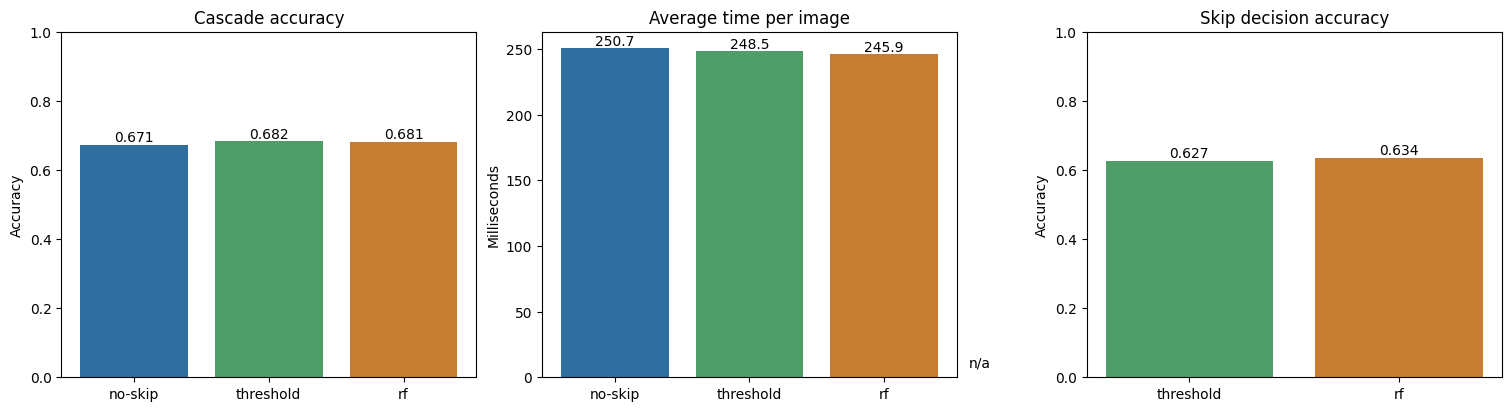

In [68]:
import matplotlib.pyplot as plt

strategies = [result["strategy"] for result in cascade_results]
accuracy = [result["accuracy"] for result in cascade_results]
time_ms = [result["time_ms_per_image"] for result in cascade_results]
skip_decision_accuracy = [result.get("skip_decision_accuracy", np.nan) for result in cascade_results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].bar(strategies, accuracy, color=["#2f6f9f", "#4f9d69", "#c77d2f"])
axes[0].set_title("Cascade accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
for i, value in enumerate(accuracy):
    axes[0].text(i, value + 0.01, f"{value:.3f}", ha="center")

axes[1].bar(strategies, time_ms, color=["#2f6f9f", "#4f9d69", "#c77d2f"])
axes[1].set_title("Average time per image")
axes[1].set_ylabel("Milliseconds")
for i, value in enumerate(time_ms):
    axes[1].text(i, value, f"{value:.1f}", ha="center", va="bottom")

axes[2].bar(strategies, skip_decision_accuracy, color=["#2f6f9f", "#4f9d69", "#c77d2f"])
axes[2].set_title("Skip decision accuracy")
axes[2].set_ylabel("Accuracy")
axes[2].set_ylim(0, 1)
for i, value in enumerate(skip_decision_accuracy):
    label = "n/a" if np.isnan(value) else f"{value:.3f}"
    y = 0.03 if np.isnan(value) else value + 0.01
    axes[2].text(i, y, label, ha="center")

plt.show()


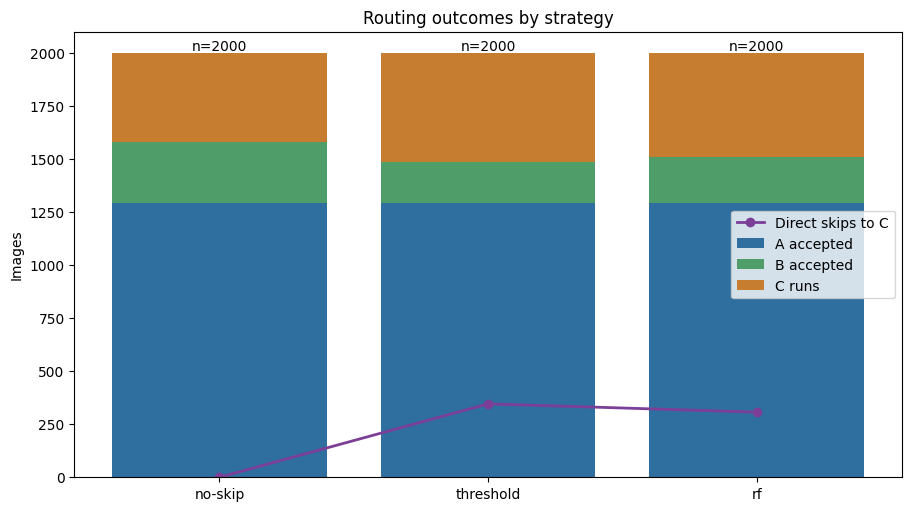

In [61]:
route_labels = ["A accepted", "B accepted", "C runs"]
route_counts = np.array([
    [result["a_successes"], result["b_successes"], result["c_runs"]]
    for result in cascade_results
])
skip_counts = np.array([result["skips"] for result in cascade_results])

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
bottom = np.zeros(len(strategies))
colors = ["#2f6f9f", "#4f9d69", "#c77d2f"]

for label, values, color in zip(route_labels, route_counts.T, colors):
    ax.bar(strategies, values, bottom=bottom, label=label, color=color)
    bottom += values

ax.plot(strategies, skip_counts, color="#7b3f98", marker="o", linewidth=2, label="Direct skips to C")
ax.set_title("Routing outcomes by strategy")
ax.set_ylabel("Images")
ax.legend()

for i, total in enumerate(bottom):
    ax.text(i, total, f"n={int(total)}", ha="center", va="bottom")

plt.show()


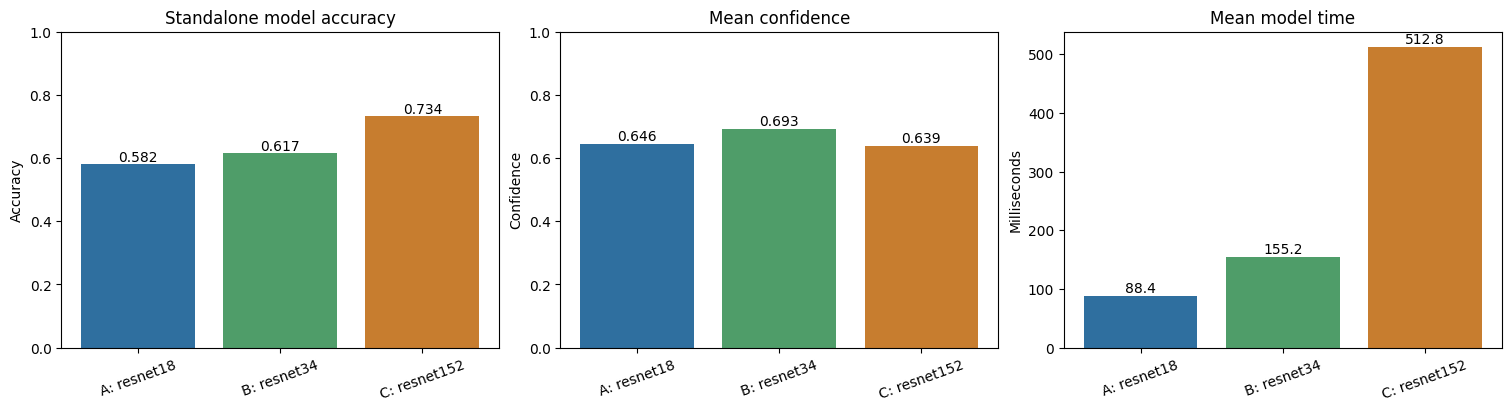

In [69]:
model_names = ["A: resnet18", "B: resnet34", "C: resnet152"]
model_caches = [a_test, b_test, c_test]
model_accuracy = [float((cache["predictions"] == cache["labels"]).mean()) for cache in model_caches]
model_confidence = [float(confidence(cache).mean()) for cache in model_caches]
model_time = [float(cache["times_ms"].mean()) for cache in model_caches]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

for ax, values, title, ylabel, ylim in [
    (axes[0], model_accuracy, "Standalone model accuracy", "Accuracy", (0, 1)),
    (axes[1], model_confidence, "Mean confidence", "Confidence", (0, 1)),
    (axes[2], model_time, "Mean model time", "Milliseconds", None),
]:
    ax.bar(model_names, values, color=["#2f6f9f", "#4f9d69", "#c77d2f"])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(*ylim)
    ax.tick_params(axis="x", rotation=20)
    for i, value in enumerate(values):
        ax.text(i, value, f"{value:.3f}" if value <= 1 else f"{value:.1f}", ha="center", va="bottom")

plt.show()


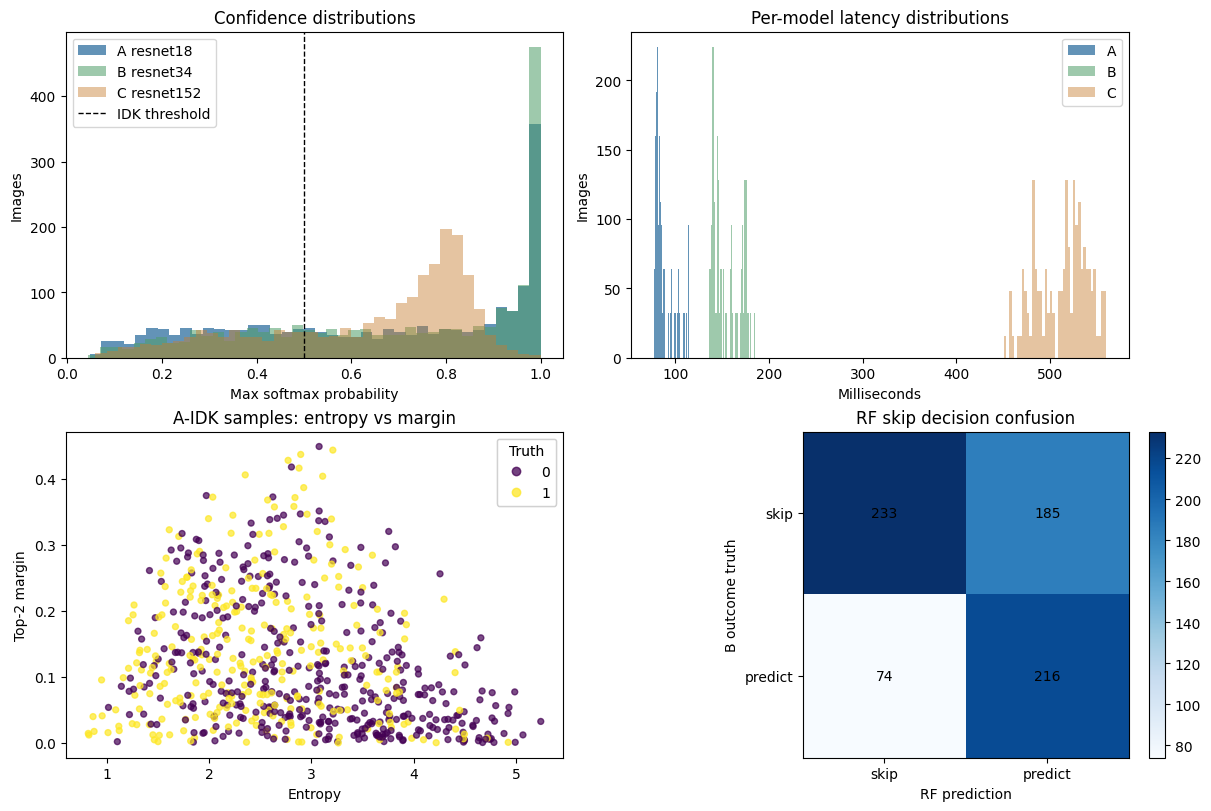

In [63]:
a_conf = confidence(a_test)
b_conf = confidence(b_test)
c_conf = confidence(c_test)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axes[0, 0].hist(a_conf, bins=40, alpha=0.75, label="A resnet18", color="#2f6f9f")
axes[0, 0].hist(b_conf, bins=40, alpha=0.55, label="B resnet34", color="#4f9d69")
axes[0, 0].hist(c_conf, bins=40, alpha=0.45, label="C resnet152", color="#c77d2f")
axes[0, 0].axvline(0.5, color="black", linestyle="--", linewidth=1, label="IDK threshold")
axes[0, 0].set_title("Confidence distributions")
axes[0, 0].set_xlabel("Max softmax probability")
axes[0, 0].set_ylabel("Images")
axes[0, 0].legend()

axes[0, 1].hist(a_test["times_ms"], bins=40, alpha=0.75, label="A", color="#2f6f9f")
axes[0, 1].hist(b_test["times_ms"], bins=40, alpha=0.55, label="B", color="#4f9d69")
axes[0, 1].hist(c_test["times_ms"], bins=40, alpha=0.45, label="C", color="#c77d2f")
axes[0, 1].set_title("Per-model latency distributions")
axes[0, 1].set_xlabel("Milliseconds")
axes[0, 1].set_ylabel("Images")
axes[0, 1].legend()

idk_mask = a_conf < 0.5
features = skip_features(a_test["probabilities"][idk_mask])
truth = np.where(b_conf[idk_mask] < 0.5, SKIP, PREDICT)
rf_pred = rf.predict(features) if len(features) else np.array([])

if len(features):
    scatter = axes[1, 0].scatter(features[:, 1], features[:, 2], c=truth, cmap="viridis", alpha=0.7, s=18)
    axes[1, 0].set_title("A-IDK samples: entropy vs margin")
    axes[1, 0].set_xlabel("Entropy")
    axes[1, 0].set_ylabel("Top-2 margin")
    legend = axes[1, 0].legend(*scatter.legend_elements(), title="Truth")
    axes[1, 0].add_artist(legend)
else:
    axes[1, 0].text(0.5, 0.5, "No A-IDK samples", ha="center", va="center")
    axes[1, 0].set_axis_off()

if len(features):
    confusion = np.array([
        [int(((truth == SKIP) & (rf_pred == SKIP)).sum()), int(((truth == SKIP) & (rf_pred == PREDICT)).sum())],
        [int(((truth == PREDICT) & (rf_pred == SKIP)).sum()), int(((truth == PREDICT) & (rf_pred == PREDICT)).sum())],
    ])
    image = axes[1, 1].imshow(confusion, cmap="Blues")
    axes[1, 1].set_title("RF skip decision confusion")
    axes[1, 1].set_xticks([0, 1], ["skip", "predict"])
    axes[1, 1].set_yticks([0, 1], ["skip", "predict"])
    axes[1, 1].set_xlabel("RF prediction")
    axes[1, 1].set_ylabel("B outcome truth")
    for row in range(2):
        for col in range(2):
            axes[1, 1].text(col, row, confusion[row, col], ha="center", va="center")
    fig.colorbar(image, ax=axes[1, 1], fraction=0.046, pad=0.04)
else:
    axes[1, 1].text(0.5, 0.5, "No RF decisions", ha="center", va="center")
    axes[1, 1].set_axis_off()

plt.show()


## 10. Current model skip-decision evaluation

Each skip-decision model predicts whether model B should be skipped. Class 0 means Skip, and class 1 means Predict. The table below compares the Random Forest skipper against the static 0.3 threshold using the currently loaded matched-frequency caches.


In [67]:
def class_metrics(y_true, y_pred, class_id):
    tp = int(((y_true == class_id) & (y_pred == class_id)).sum())
    fp = int(((y_true != class_id) & (y_pred == class_id)).sum())
    fn = int(((y_true == class_id) & (y_pred != class_id)).sum())

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return precision, recall, f1


def confusion_counts(y_true, y_pred):
    return np.array([
        [int(((y_true == SKIP) & (y_pred == SKIP)).sum()), int(((y_true == SKIP) & (y_pred == PREDICT)).sum())],
        [int(((y_true == PREDICT) & (y_pred == SKIP)).sum()), int(((y_true == PREDICT) & (y_pred == PREDICT)).sum())],
    ])


a_conf = confidence(a_test)
b_conf = confidence(b_test)
a_idk = a_conf < 0.5

skip_y_true = np.where(b_conf[a_idk] < 0.5, SKIP, PREDICT).astype(np.int64)
rf_y_pred = rf.predict(skip_features(a_test["probabilities"][a_idk])).astype(np.int64)
threshold_y_pred = np.where(a_conf[a_idk] < 0.3, SKIP, PREDICT).astype(np.int64)

skip_eval_models = [
    ("Random Forest", rf_y_pred),
    ("Threshold (0.3)", threshold_y_pred),
]

skip_metric_rows = []
skip_confusions = {}
for model_name, y_pred in skip_eval_models:
    accuracy = float((skip_y_true == y_pred).mean()) if len(skip_y_true) else 0.0
    skip_confusions[model_name] = confusion_counts(skip_y_true, y_pred)
    for class_id, class_name in [(SKIP, "Skip (0)"), (PREDICT, "Predict (1)")]:
        precision, recall, f1 = class_metrics(skip_y_true, y_pred, class_id)
        skip_metric_rows.append({
            "Model": model_name,
            "Class": class_name,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "Accuracy": accuracy,
        })

print(f"Skip-decision samples: {len(skip_y_true)}")
print("Model             Class        Precision  Recall  F1-Score  Accuracy")
for row_index, row in enumerate(skip_metric_rows):
    accuracy_text = f"{row['Accuracy']:.2f}" if row_index % 2 == 0 else ""
    print(
        f"{row['Model']:<17} {row['Class']:<12} "
        f"{row['Precision']:.2f}       {row['Recall']:.2f}    {row['F1-Score']:.2f}      {accuracy_text}"
    )


Skip-decision samples: 708
Model             Class        Precision  Recall  F1-Score  Accuracy
Random Forest     Skip (0)     0.76       0.56    0.64      0.63
Random Forest     Predict (1)  0.54       0.74    0.63      
Threshold (0.3)   Skip (0)     0.72       0.60    0.65      0.63
Threshold (0.3)   Predict (1)  0.54       0.67    0.60      
